In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs

## 1. 데이터 생성

### `make_blobs` 가 받는 argument 각각의 의미를 알아보세요.

n_samples : 생성할 데이터 포인트 총 개수

centers : 클러스터 중심

cluster_std : 각 클러스터 퍼짐 정도 (표준편차)

random_state : 난수 시드

In [2]:
np.random.seed(42)
X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

## 2. K-means 클러스터링
K-means 알고리즘을 사용하여 데이터셋을 4개의 클러스터로 나누어 봅시다.

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

### 클러스터가 더 퍼져 있으면 K-means 결과는 어떻게 달라질까요? 결과를 해석해보세요.

cluster_std = 2.0 처럼 클러스터가 더 퍼져 있으면, 각 클러스터 간 서로 겹치는 영역이 증가한다. 따라서 오분류가 발생할 가능성이 높아진다. 

In [4]:
X_varied, y_varied = make_blobs(n_samples=300, centers=4, cluster_std=2.0, random_state=42)
kmeans_varied = KMeans(n_clusters=4, random_state=42)
kmeans_varied_labels = kmeans_varied.fit_predict(X_varied)

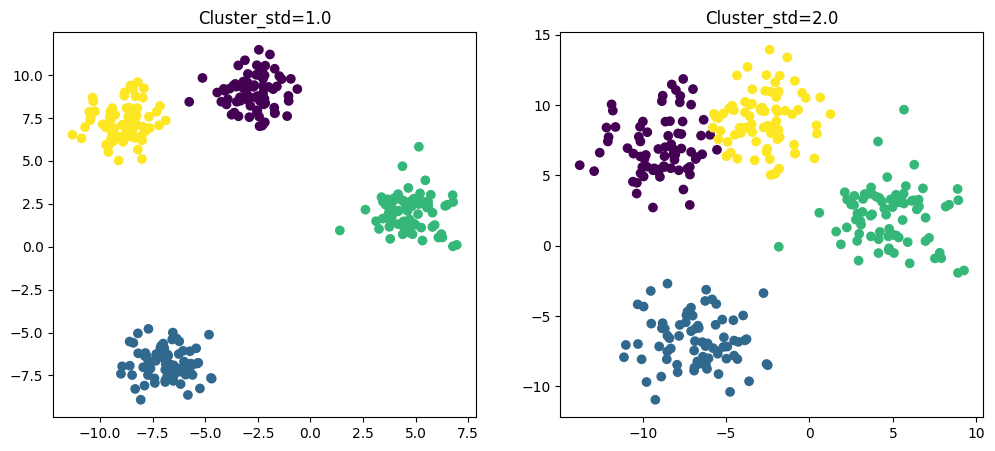

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
plt.title('Cluster_std=1.0')
plt.subplot(1, 2, 2)
plt.scatter(X_varied[:, 0], X_varied[:, 1], c=kmeans_varied_labels, cmap='viridis')
plt.title('Cluster_std=2.0')
plt.show()

## 3. 계층적 클러스터링
계층적 클러스터링을 사용하여 데이터를 4개의 클러스터로 그룹화해봅시다

In [6]:
hierarchical = AgglomerativeClustering(n_clusters=4)
hierarchical_labels = hierarchical.fit_predict(X)

## 실습 2: Hierarchical Clustering linkage 방법 비교
### 서로 다른 linkage 방법(single, complete, average)에 따라 클러스터링 결과가 어떻게 달라지나요?

single : 최소 거리를 사용하여 chaining 현상이 발생하며, 한 클러스터가 길게 늘어나게 되며 낮은 거리에서 빠르게 이어진다. 

complete : 최대 거리를 사용하여 합쳐지기까지 거리가 더 증가하며, 조밀한 클러스터를 만든다. 

average : 평균 거리를 사용하여 single, complete의 중간 성향을 보이며, 안정적인 클러스터를 보인다. 

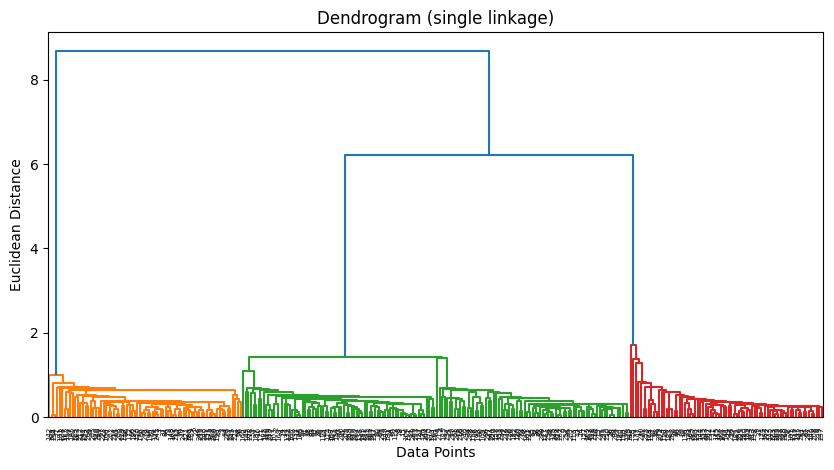

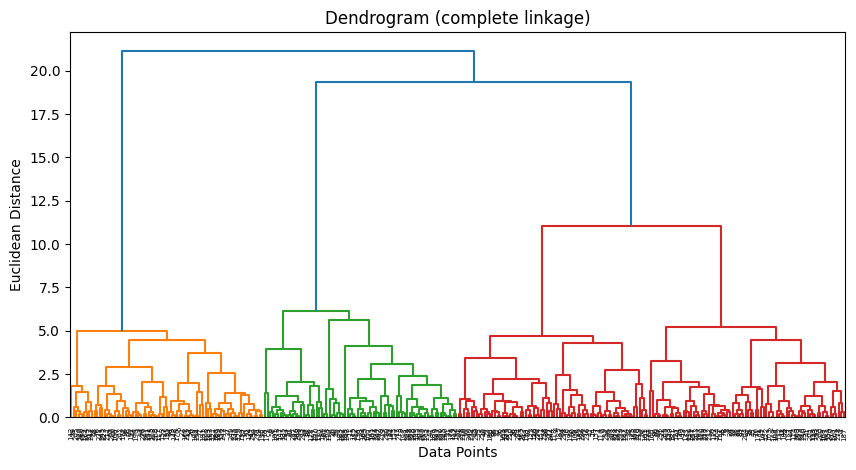

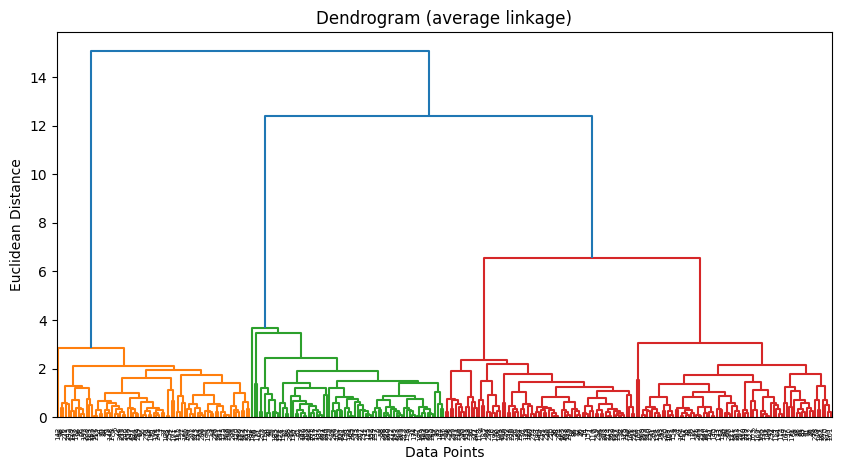

In [7]:
for method in ['single', 'complete', 'average']:
    plt.figure(figsize=(10, 5))
    Z = linkage(X, method=method)
    dendrogram(Z)
    plt.title(f'Dendrogram ({method} linkage)')
    plt.xlabel('Data Points')
    plt.ylabel('Euclidean Distance')
    plt.show()

## 4. GMM (Gaussian Mixture Model)
GMM을 사용하여 데이터를 4개의 클러스터로 분류해봅시다

In [8]:
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X)

### GMM에서 가우시안 개수를 조정하면 클러스터링 결과는 어떻게 달라질까요?

실제 군집 구조 : 4개

n_components = 3 : 실제 군집 구조에 비해 적어, 서로 다른 군집을 하나로 합쳐 설명하려 한다. 

n_components = 4 : 실제 군집 구조와 동일하여 가장 적절하게 분할한다. 

n_components = 5 : 실제 군집 구조보다 많아, 하나의 군집을 둘로 쪼개어 설명하려 한다. 

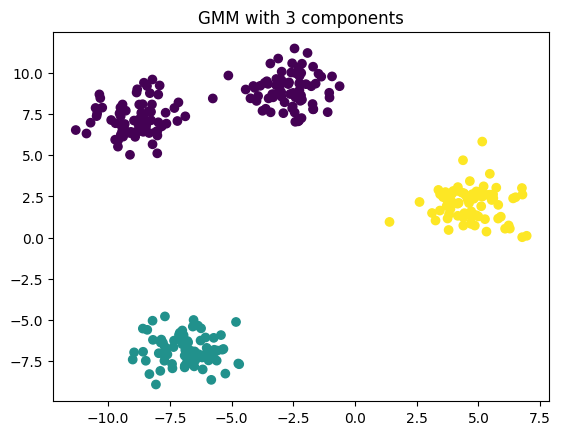

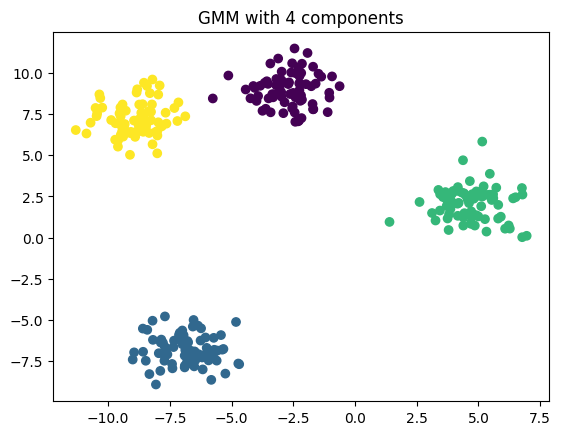

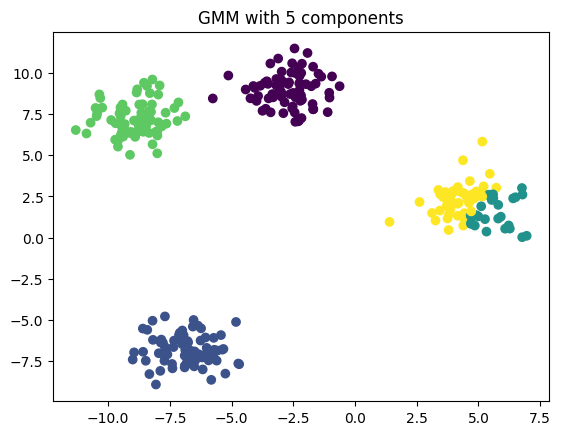

In [9]:
for n in [3, 4, 5]:
    gmm_test = GaussianMixture(n_components=n, random_state=42)
    gmm_test_labels = gmm_test.fit_predict(X)
    plt.scatter(X[:, 0], X[:, 1], c=gmm_test_labels, cmap='viridis')
    plt.title(f'GMM with {n} components')
    plt.show()

## 5-1. Silhouette Score

클러스터의 수를 결정하는 데 쓰이는 method를 각각 설명해주세요.

silhouette score : 각 데이터에 대해 같은 클러스터 내부 평균 거리와 가장 가까운 다른 클러스터까지의 평균 거리, 즉 응집도와 분리도를 비교하여 scoring 한다. 1에 가까울수록 잘 응집되고, 분리되었음을 뜻한다. 

elbow method : k가 증가함에 따라, WCSS(군집 내 제곰합)의 감소폭이 급격히 줄어드는 점을 찾는다. 

In [10]:
kmeans_silhouette = silhouette_score(X, kmeans_labels)
hierarchical_silhouette = silhouette_score(X, hierarchical_labels)
gmm_silhouette = silhouette_score(X, gmm_labels)

### Silhouette Score를 기준으로 보면, 가장 적절한 클러스터 개수는 몇 개일까요?

silhouette score가 가장 높은 k=4 (0.8)이 적절하다. 

In [11]:
silhouette_scores = {}
k_values = range(2, 10)
for k in k_values:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    labels = kmeans_test.fit_predict(X)
    silhouette_scores[k] = silhouette_score(X, labels)

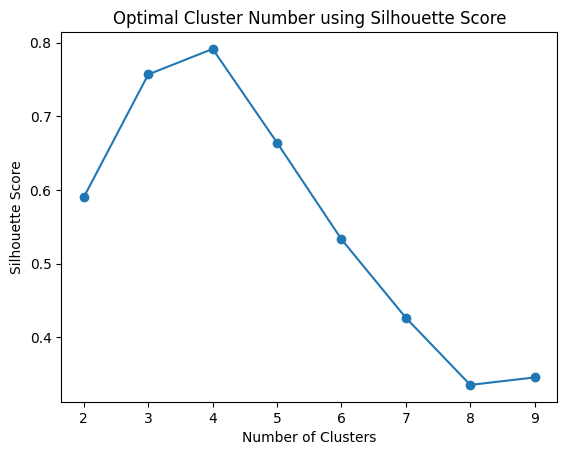

In [12]:
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Optimal Cluster Number using Silhouette Score')
plt.show()

## 5-2. Elbow Method

In [13]:
wcss = []
k_values = range(1, 11)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

### Elbow Method를 기준으로 보면, 'elbow point'는 몇 개의 클러스터를 선택해야 한다고 말하나요?

감소폭이 급격하게 줄어드는 k=4 가 적절하다. 

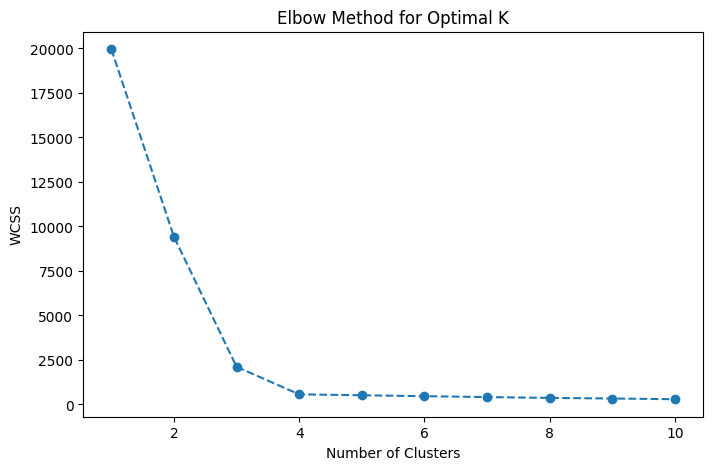

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()